In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.util import img_as_uint

import os
import tifffile
import pickle

from skimage.transform import estimate_transform, warp
from tqdm import tqdm

from skimage.filters import threshold_triangle, threshold_otsu
from skimage.feature import peak_local_max
from skimage.util import img_as_uint, img_as_ubyte, img_as_float
from skimage.exposure import rescale_intensity
import matplotlib.pyplot as plt

# image registration

# dot detection

## whole image

In [97]:
def detect_dots(img):
    img = rescale_intensity(img)
    high_threshold = (img > threshold_otsu(img)*5).astype(float)
    img = img * high_threshold
    thre_abs = threshold_otsu(img)*0.7
    return peak_local_max(img,threshold_abs = thre_abs)

def filter_dots(dots, background):
    thre_background = threshold_triangle(background) * 5
    return dots[background[dots[:, 0], dots[:, 1]] < thre_background]

In [83]:
registered_im_dir = r'..\coculture1\00_registration\registered'
channels = ['C1', 'C2', 'C3', 'C4']
cycles = ['01']

In [84]:
ch = 'C1'
channel_dir = os.path.join(registered_im_dir, ch)
channel_fn_dict = {}
for im in os.listdir(channel_dir):
    if im.endswith('.tif'):
        cycle = im.split('_')[1]
        channel_fn_dict[cycle] = im[3:]

In [85]:
channel_fn_dict

{'01': '01_coculture1_empty_cxcl14_col1a1.tif'}

In [86]:
genes = [['EMPTY', 'CXCL14', 'COL1A1']]

In [67]:
mask = tifffile.imread(r"..\00_segmentation\coculture1_cycle1_segmentation_reference_cp_masks.tif")

In [68]:
mask = mask > 0

In [108]:
detected_dots = []
for i, cycle in tqdm(enumerate(cycles)):

    ch2 = tifffile.imread(os.path.join(registered_im_dir, 'C2', 'C2_'+channel_fn_dict[cycle]))
    ch2 = img_as_float(ch2)
    ch2 = ch2 * mask
    ch3 = tifffile.imread(os.path.join(registered_im_dir, 'C3', 'C3_'+channel_fn_dict[cycle]))
    ch3 = img_as_float(ch3)
    ch3 = ch3 * mask
    ch4 = tifffile.imread(os.path.join(registered_im_dir, 'C4', 'C4_'+channel_fn_dict[cycle]))
    ch4 = img_as_float(ch4)
    ch4 = ch4 * mask
    print('Images loaded')

    gene = genes[i]
    if not gene[0] == 'EMPTY':
        print('C2 detecting '+gene[0])
        ch2_dots = detect_dots(ch2)
        ch2_dot_filter = filter_dots(ch2_dots, ch3)
        print('C2 detected image')
    else:
        ch2_dot_filter = np.zeros((2,2), dtype=int)
        print('C2 skipped')
    if not gene[1] == 'EMPTY':
        print('C3 detecting '+gene[1])
        ch3_dots = detect_dots(ch3)
        ch3_dot_filter = filter_dots(ch3_dots, ch2)
        print('C3 detected image')
    else:
        ch3_dot_filter = np.zeros((2,2), dtype=int)
        print('C3 skipped')
    if not gene[2] == 'EMPTY':
        print('C4 detecting '+gene[2])
        ch4_dots = detect_dots(ch4)
        ch4_dot_filter = filter_dots(ch4_dots, ch3)
        print('C4 detected image')
    else:
        ch4_dot_filter = np.zeros((2,2), dtype=int)
        print('C4 skipped')

    ch2_df = pd.DataFrame(ch2_dot_filter, columns=['row', 'col'])
    ch3_df = pd.DataFrame(ch3_dot_filter, columns=['row', 'col'])
    ch4_df = pd.DataFrame(ch4_dot_filter, columns=['row', 'col'])
    detected_dots.append([ch2_df, ch3_df, ch4_df])

0it [00:00, ?it/s]

Images loaded
C2 skipped
C3 detecting CXCL14
C3 detected image
C4 detecting COL1A1


1it [18:05, 1085.28s/it]

C4 detected image


In [109]:
n_cycles = 1
n_genes = 3
for cycle in detected_dots:
    for i in range(n_cycles):
        for j in range(n_genes):
            detected_dots[i][j]['gene'] = genes[i][j]

In [110]:
detected_dots_df = (detected_dots[0])
detected_dots_df = pd.concat(detected_dots_df, ignore_index=True)

In [111]:
detected_dots_df.to_csv(r'..\coculture1\00_analysis\detected_dots_whole_image.csv')

## detect by grid, mannually set the grid

In [ ]:
detected_dots = []
for i, cycle in tqdm(enumerate(cycles)):

    ch2 = tifffile.imread(os.path.join(registered_im_dir, 'C2', 'C2_'+channel_fn_dict[cycle]))
    ch2 = img_as_float(ch2)
    ch2 = ch2 * mask
    ch2_dimg = da.from_array(ch2, chunks=(1959, 1959))
    ch3 = tifffile.imread(os.path.join(registered_im_dir, 'C3', 'C3_'+channel_fn_dict[cycle]))
    ch3 = img_as_float(ch3)
    ch3 = ch3 * mask
    ch3_dimg = da.from_array(ch3, chunks=(1959, 1959))
    ch4 = tifffile.imread(os.path.join(registered_im_dir, 'C4', 'C4_'+channel_fn_dict[cycle]))
    ch4 = img_as_float(ch4)
    ch4 = ch4 * mask
    ch4_dimg = da.from_array(ch4, chunks=(1959, 1959))
    print('Images loaded')

    gene = genes[i]
    if not gene[0] == 'EMPTY':
        print('C2 detecting '+gene[0])
        mapped = ch2_dimg.map_blocks(detect_block, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch2_dots = np.vstack([c for c in dot_chunks if c.size])
        ch2_dot_filter = filter_dots(ch2_dots, ch3)
        print('C2 detected image')
    else:
        ch2_dot_filter = np.zeros((2,2), dtype=int)
        print('C2 skipped')
    if not gene[1] == 'EMPTY':
        print('C3 detecting '+gene[1])
        mapped = ch3_dimg.map_blocks(detect_block, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch3_dots = np.vstack([c for c in dot_chunks if c.size])
        ch3_dot_filter = filter_dots(ch3_dots, ch2)
        print('C3 detected image')
    else:
        ch3_dot_filter = np.zeros((2,2), dtype=int)
        print('C3 skipped')
    if not gene[2] == 'EMPTY':
        print('C4 detecting '+gene[2])
        mapped = ch4_dimg.map_blocks(detect_block, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch4_dots = np.vstack([c for c in dot_chunks if c.size])
        ch4_dot_filter = filter_dots(ch4_dots, ch2)
        print('C4 detected image')
    else:
        ch4_dot_filter = np.zeros((2,2), dtype=int)
        print('C4 skipped')

    ch2_df = pd.DataFrame(ch2_dot_filter, columns=['row', 'col'])
    ch3_df = pd.DataFrame(ch3_dot_filter, columns=['row', 'col'])
    ch4_df = pd.DataFrame(ch4_dot_filter, columns=['row', 'col'])
    detected_dots.append([ch2_df, ch3_df, ch4_df])

## detect by grid

In [7]:
import dask.array as da
import dask

In [8]:
# dimg = da.from_array(ch3, chunks=(2048, 2048))

In [9]:
# dimg

In [10]:
def detect_dots_ch3(img):
    img = rescale_intensity(img)
    thre_abs = threshold_triangle(img)*0.7
    # thre = img > thre_abs
    # tifffile.imwrite(os.path.join(r'..\coculture1\00_analysis\threshold\c3',filename+'_threshold.tif'), thre)
    # tifffile.imwrite(os.path.join(r'..\coculture1\00_analysis\threshold\c3',filename+'_image.tif'), img_as_uint(img))
    return peak_local_max(img,min_distance=15,threshold_abs=thre_abs)

def detect_dots_ch4(img):
    img = rescale_intensity(img)
    # high_threshold = (img > threshold_otsu(img)*3).astype(float)
    # img = img * high_threshold
    thre_abs = threshold_triangle(img)*0.5
    # thre = img > thre_abs
    # tifffile.imwrite(os.path.join(r'..\coculture1\00_analysis\threshold\c4',filename+'_threshold.tif'), thre)
    # tifffile.imwrite(os.path.join(r'..\coculture1\00_analysis\threshold\c4',filename+'_image.tif'), img_as_uint(img))
    return peak_local_max(img,min_distance=3,threshold_abs=thre_abs)

def filter_dots(dots, background):
    thre_background = threshold_triangle(background) * 5
    return dots[background[dots[:, 0], dots[:, 1]] < thre_background]

In [11]:
registered_im_dir = r'..\coculture2\00_registration\registered'
channels = ['C1', 'C2', 'C3', 'C4']
cycles = ['01']

In [12]:
ch = 'C1'
channel_dir = os.path.join(registered_im_dir, ch)
channel_fn_dict = {}
for im in os.listdir(channel_dir):
    if im.endswith('.tif'):
        cycle = im.split('_')[1]
        channel_fn_dict[cycle] = im[3:]

In [13]:
channel_fn_dict

{'01': '01_coculture2_empty_cxcl14_col1a1.tif'}

In [14]:
genes = [['EMPTY', 'CXCL14', 'COL1A1']]

In [15]:
def detect_block_ch3(block, block_info=None):
    # block is a NumPy array
    # chunk_index = block_info[0]['chunk-location']
    # filename = f"ch3_block_{chunk_index[0]}_{chunk_index[1]}"
    dots = detect_dots_ch3(block)
    if block_info is not None and dots.size:
        # block_info[0]['array-location'] = ((r0,r1),(c0,c1))
        (r0, _), (c0, _) = block_info[0]['array-location']
        dots = dots.astype(int)
        dots[:, 0] += r0
        dots[:, 1] += c0
    # return a 2‑D array of shape (n_dots, 2); empty blocks => shape (0,2)
    return dots
def detect_block_ch4(block, block_info=None):
    # block is a NumPy array
    # chunk_index = block_info[0]['chunk-location']
    # filename = f"ch4_block_{chunk_index[0]}_{chunk_index[1]}"
    dots = detect_dots_ch4(block)
    if block_info is not None and dots.size:
        # block_info[0]['array-location'] = ((r0,r1),(c0,c1))
        (r0, _), (c0, _) = block_info[0]['array-location']
        dots = dots.astype(int)
        dots[:, 0] += r0
        dots[:, 1] += c0
    # return a 2‑D array of shape (n_dots, 2); empty blocks => shape (0,2)
    return dots

In [16]:
# mapped = dimg.map_blocks(detect_block, dtype=object, drop_axis=[0,1])

In [17]:
# mapped

In [18]:
# dot_chunks = mapped.compute()
# all_dots = np.vstack([c for c in dot_chunks if c.size])

In [19]:
mask = tifffile.imread(r"..\coculture2\00_segmentation\segmentation_reference_cp_masks_filtered.tif")

In [20]:
mask = mask > 0

In [21]:
dask.config.set(scheduler="threads", num_workers=4)

In [22]:
detected_dots = []
for i, cycle in tqdm(enumerate(cycles)):

    ch2 = tifffile.imread(os.path.join(registered_im_dir, 'C2', 'C2_'+channel_fn_dict[cycle]))
    ch2 = img_as_float(ch2)
    ch2 = ch2 * mask
    ch2_dimg = da.from_array(ch2, chunks=(512, 512))
    ch3 = tifffile.imread(os.path.join(registered_im_dir, 'C3', 'C3_'+channel_fn_dict[cycle]))
    ch3 = img_as_float(ch3)
    ch3 = ch3 * mask
    ch3_dimg = da.from_array(ch3, chunks=(512, 512))
    ch4 = tifffile.imread(os.path.join(registered_im_dir, 'C4', 'C4_'+channel_fn_dict[cycle]))
    ch4 = img_as_float(ch4)
    ch4 = ch4 * mask
    ch4_dimg = da.from_array(ch4, chunks=(512, 512))
    print('Images loaded')

    gene = genes[i]
    if not gene[0] == 'EMPTY':
        print('C2 detecting '+gene[0])
        mapped = ch2_dimg.map_blocks(detect_block_ch3, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch2_dots = np.vstack([c for c in dot_chunks if c.size])
        ch2_dot_filter = filter_dots(ch2_dots, ch3)
        print('C2 detected image')
    else:
        ch2_dot_filter = np.zeros((2,2), dtype=int)
        print('C2 skipped')
    if not gene[1] == 'EMPTY':
        print('C3 detecting '+gene[1])
        mapped = ch3_dimg.map_blocks(detect_block_ch3, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch3_dots = np.vstack([c for c in dot_chunks if c.size])
        # ch3_dot_filter = filter_dots(ch3_dots, ch2)
        ch3_dot_filter = ch3_dots
        print('C3 detected image')
    else:
        ch3_dot_filter = np.zeros((2,2), dtype=int)
        print('C3 skipped')
    if not gene[2] == 'EMPTY':
        print('C4 detecting '+gene[2])
        mapped = ch4_dimg.map_blocks(detect_block_ch4, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch4_dots = np.vstack([c for c in dot_chunks if c.size])
        # ch4_dot_filter = filter_dots(ch4_dots, ch2)
        ch4_dot_filter = ch4_dots
        print('C4 detected image')
    else:
        ch4_dot_filter = np.zeros((2,2), dtype=int)
        print('C4 skipped')

    ch2_df = pd.DataFrame(ch2_dot_filter, columns=['row', 'col'])
    ch3_df = pd.DataFrame(ch3_dot_filter, columns=['row', 'col'])
    ch4_df = pd.DataFrame(ch4_dot_filter, columns=['row', 'col'])
    detected_dots.append([ch2_df, ch3_df, ch4_df])

0it [00:00, ?it/s]

Images loaded
C2 skipped
C3 detecting CXCL14
C3 detected image
C4 detecting COL1A1


1it [05:50, 350.58s/it]

C4 detected image


In [23]:
n_cycles = 1
n_genes = 3
for cycle in detected_dots:
    for i in range(n_cycles):
        for j in range(n_genes):
            detected_dots[i][j]['gene'] = genes[i][j]

In [24]:
detected_dots_df = (detected_dots[0])
detected_dots_df = pd.concat(detected_dots_df, ignore_index=True)

In [25]:
detected_dots_df.to_csv(r'..\coculture2\00_analysis\detected_dots_whole_image.csv')

## Detect dots in grid, using blob detection

In [174]:
from skimage.feature import blob_log

In [ ]:
def detect_blobs(img, min_sigma=2, max_sigma=5, threshold=0.01):
    """Detect spots in a FISH image using Laplacian of Gaussian blob detection.

    Returns an (N,2) array of (row, col) coordinates for each blob found.
    The radius returned by blob_log is dropped here since downstream code only
    uses the pixel position.
    """
    # blob_log returns (y, x, sigma) for each detected blob
    blobs = blob_log(img, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)
    if blobs.size == 0:
        return np.zeros((0,2), dtype=int)
    coords = blobs[:, :2].astype(int)
    return coords

In [38]:
crop_shape = pd.read_pickle(r"Y:\coskun-lab-cedar\Zhou\12_MSG\20260218_coculture\coculture1\00_analysis\blob_test\crop.pkl")
crop_shape = crop_shape.astype(int)

In [39]:
ch2 = tifffile.imread(os.path.join(registered_im_dir, 'C2', 'C2_'+channel_fn_dict['01']))
ch3 = tifffile.imread(os.path.join(registered_im_dir, 'C3', 'C3_'+channel_fn_dict['01']))
ch4 = tifffile.imread(os.path.join(registered_im_dir, 'C4', 'C4_'+channel_fn_dict['01']))

In [40]:
ch2_crop = ch2[crop_shape[0,0]:crop_shape[2,0],crop_shape[0,1]:crop_shape[1,1]]
ch3_crop = ch3[crop_shape[0,0]:crop_shape[2,0],crop_shape[0,1]:crop_shape[1,1]]
ch4_crop = ch4[crop_shape[0,0]:crop_shape[2,0],crop_shape[0,1]:crop_shape[1,1]]
mask_crop = mask[crop_shape[0,0]:crop_shape[2,0],crop_shape[0,1]:crop_shape[1,1]]

In [41]:
ch2_crop = img_as_float(ch2_crop)
ch2_crop = ch2_crop * mask_crop
ch3_crop = img_as_float(ch3_crop)
ch3_crop = ch3_crop * mask_crop
ch4_crop = img_as_float(ch4_crop)
ch4_crop = ch4_crop * mask_crop

In [52]:
test_dots = detect_blobs(ch3_crop, threshold=threshold_otsu(ch3_crop))

In [53]:
test_dots.shape

(4873, 2)

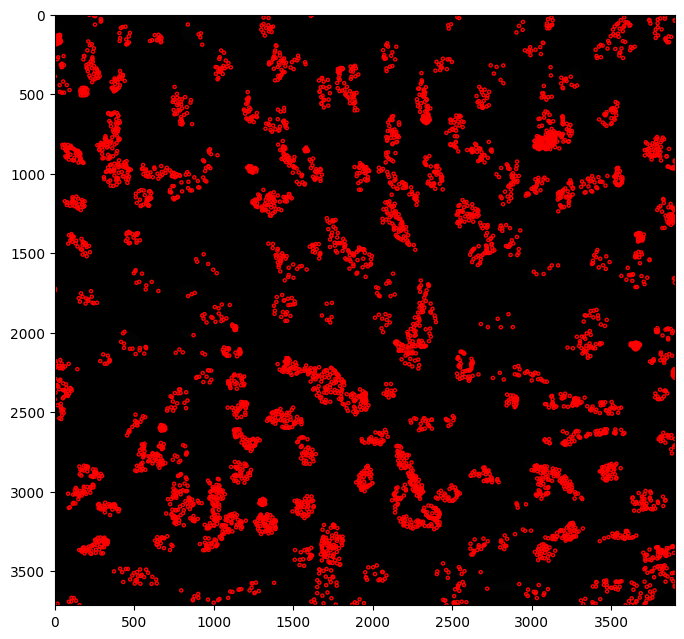

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.imshow(img_as_ubyte(ch3_crop), cmap='gray')
ax.scatter(test_dots[:,1], test_dots[:,0], marker='o', s=5, facecolor='none', edgecolor='red')
plt.savefig(r'..\coculture1\00_analysis\blob_test\ch3.png')
plt.show()

In [ ]:
test_dots = detect_blobs(ch4_crop, threshold=threshold_otsu(ch4_crop)*)

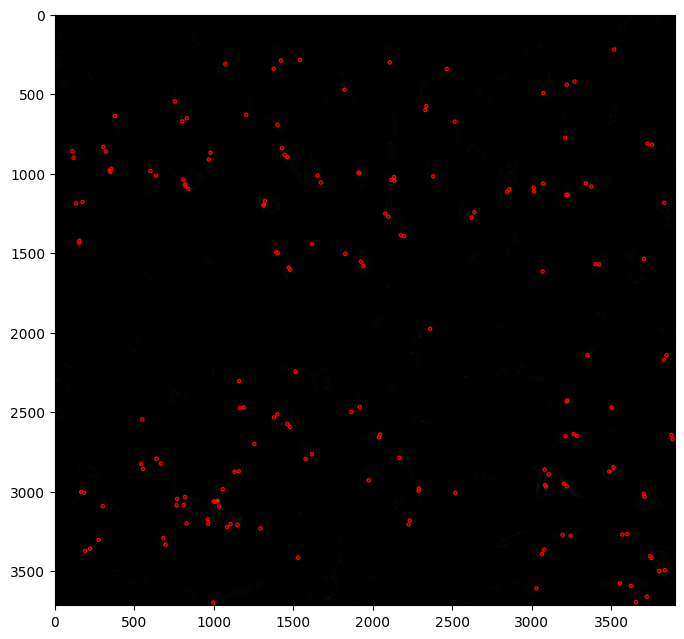

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.imshow(img_as_ubyte(ch4_crop), cmap='gray')
ax.scatter(test_dots[:,1], test_dots[:,0], marker='o', s=5, facecolor='none', edgecolor='red')
plt.savefig(r'..\coculture1\00_analysis\blob_test\ch4.png')
plt.show()

In [ ]:
def detect_block_blob_ch3(block, block_info=None):
    # block is a NumPy array
    dots = detect_blobs(block, threshold=threshold_otsu(block)*0.8)
    if block_info is not None and dots.size:
        # block_info[0]['array-location'] = ((r0,r1),(c0,c1))
        (r0, _), (c0, _) = block_info[0]['array-location']
        dots = dots.astype(int)
        dots[:, 0] += r0
        dots[:, 1] += c0
    # return a 2‑D array of shape (n_dots, 2); empty blocks => shape (0,2)
    return dots

def detect_block_blob_ch4(block, block_info=None):
    # block is a NumPy array
    dots = detect_blobs(block, threshold=threshold_otsu(block)*0.8)
    if block_info is not None and dots.size:
        # block_info[0]['array-location'] = ((r0,r1),(c0,c1))
        (r0, _), (c0, _) = block_info[0]['array-location']
        dots = dots.astype(int)
        dots[:, 0] += r0
        dots[:, 1] += c0
    # return a 2‑D array of shape (n_dots, 2); empty blocks => shape (0,2)
    return dots

In [ ]:
detected_dots = []
for i, cycle in tqdm(enumerate(cycles)):

    ch2 = tifffile.imread(os.path.join(registered_im_dir, 'C2', 'C2_'+channel_fn_dict[cycle]))
    ch2 = img_as_float(ch2)
    ch2 = ch2 * mask
    ch2_dimg = da.from_array(ch2, chunks=(1959, 1959))
    ch3 = tifffile.imread(os.path.join(registered_im_dir, 'C3', 'C3_'+channel_fn_dict[cycle]))
    ch3 = img_as_float(ch3)
    ch3 = ch3 * mask
    ch3_dimg = da.from_array(ch3, chunks=(1959, 1959))
    ch4 = tifffile.imread(os.path.join(registered_im_dir, 'C4', 'C4_'+channel_fn_dict[cycle]))
    ch4 = img_as_float(ch4)
    ch4 = ch4 * mask
    ch4_dimg = da.from_array(ch4, chunks=(1959, 1959))
    print('Images loaded')

    gene = genes[i]
    if not gene[0] == 'EMPTY':
        print('C2 detecting '+gene[0])
        mapped = ch2_dimg.map_blocks(detect_block_blob, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch2_dots = np.vstack([c for c in dot_chunks if c.size])
        ch2_dot_filter = filter_dots(ch2_dots, ch3)
        print('C2 detected image')
    else:
        ch2_dot_filter = np.zeros((2,2), dtype=int)
        print('C2 skipped')
    if not gene[1] == 'EMPTY':
        print('C3 detecting '+gene[1])
        mapped = ch3_dimg.map_blocks(detect_block_blob, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch3_dots = np.vstack([c for c in dot_chunks if c.size])
        ch3_dot_filter = filter_dots(ch3_dots, ch2)
        print('C3 detected image')
    else:
        ch3_dot_filter = np.zeros((2,2), dtype=int)
        print('C3 skipped')
    if not gene[2] == 'EMPTY':
        print('C4 detecting '+gene[2])
        mapped = ch4_dimg.map_blocks(detect_block_blob, dtype=object, drop_axis=[0,1])
        dot_chunks = mapped.compute()
        ch4_dots = np.vstack([c for c in dot_chunks if c.size])
        ch4_dot_filter = filter_dots(ch4_dots, ch2)
        print('C4 detected image')
    else:
        ch4_dot_filter = np.zeros((2,2), dtype=int)
        print('C4 skipped')

    ch2_df = pd.DataFrame(ch2_dot_filter, columns=['row', 'col'])
    ch3_df = pd.DataFrame(ch3_dot_filter, columns=['row', 'col'])
    ch4_df = pd.DataFrame(ch4_dot_filter, columns=['row', 'col'])
    detected_dots.append([ch2_df, ch3_df, ch4_df])

# Dots per mask

In [26]:
from skimage.measure import regionprops_table
from skimage import io
import pandas as pd
import tifffile

In [27]:
detected_dots_df = pd.read_csv(r'..\coculture2\00_analysis\detected_dots_whole_image.csv', index_col=0)

In [28]:
mask = tifffile.imread(r"..\coculture2\00_segmentation\segmentation_reference_cp_masks_filtered.tif")

In [29]:
genes = [['EMPTY', 'CXCL14', 'COL1A1']]

In [30]:
detected_dots_df['label'] = mask[detected_dots_df['row'], detected_dots_df['col']]

In [31]:
detected_dots_df_filtered = detected_dots_df[detected_dots_df['label'] > 0]

In [32]:
detected_dots_df_filtered.to_csv(r'..\coculture2\00_analysis\detected_dots_filtered.csv')

In [33]:
detected_dots_df

,row,col,gene,label
0,0,0,EMPTY,0
1,0,0,EMPTY,0
2,1987,16152,CXCL14,99
3,1660,21125,CXCL14,60
4,1782,14048,CXCL14,78
...,...,...,...,...
746631,19257,13333,COL1A1,7978
746632,8050,1530,COL1A1,2917
746633,8051,2504,COL1A1,2922
746634,13064,20652,COL1A1,5430


In [34]:
genes = detected_dots_df['gene'].unique().tolist()
gene_count = {}
for gene in genes:
    gene_df = detected_dots_df_filtered[detected_dots_df_filtered['gene'] == gene]
    gene_count[gene] = gene_df['label'].value_counts()

In [35]:
gene_count_df = pd.DataFrame(gene_count)
gene_count_df = gene_count_df.fillna(0)

In [36]:
gene_count_df

,EMPTY,CXCL14,COL1A1
label,,,
2,0.0,1.0,0.0
5,0.0,1.0,0.0
7,0.0,1.0,0.0
9,0.0,1.0,0.0
11,0.0,2.0,0.0
...,...,...,...
10425,0.0,9.0,44.0
10428,0.0,8.0,31.0
10444,0.0,5.0,11.0


In [37]:
gene_count_df.drop(columns=['EMPTY'], inplace=True)

In [38]:
cells_properties = regionprops_table(mask, properties=['label', 'area', 'centroid', 'eccentricity'])
cells_properties_df = pd.DataFrame(cells_properties)

In [39]:
cells_properties_df.rename(columns={'centroid-0': 'row', 'centroid-1': 'col'}, inplace=True)

In [40]:
cells_properties_df.index = cells_properties_df['label']

In [41]:
# merge the two dataframes
cells_properties_df = cells_properties_df.merge(gene_count_df, left_index=True, right_index=True)
cells_properties_df = cells_properties_df.fillna(0)

In [42]:
cells_properties_df.shape

(8806, 7)

In [43]:
cells_properties_df = cells_properties_df[cells_properties_df['area']>100]

In [44]:
cells_properties_df.shape

(8729, 7)

In [45]:
cells_properties_df = cells_properties_df[cells_properties_df['eccentricity']<0.99]

In [46]:
cells_properties_df.shape

(8578, 7)

In [47]:
cells_properties_df.to_csv(r'..\coculture2\00_analysis\expression.csv')